In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
# %matplotlib inline

In [2]:
# df=pd.DataFrame()

In [4]:
# for i in range(1,10):
#     df=pd.concat([df,pd.read_csv(rf"D:\DataSets\AlgoTrading\BITCIN\Trend{i}.csv")],ignore_index=True)
# df.to_csv('combined_tend_BIT.csv')
# print(df.index)


In [3]:
df=pd.read_csv('combined_tend_BIT.csv')
df.drop(['Unnamed: 0.1','Unnamed: 0'],axis=1,inplace=True)
df

,Diff,Time1,Start,End,Time2
0,-16.968750,60.0,2026-06-26 05:30:00+05:30,2026-06-26 05:31:00+05:30,60.0
1,82.468750,60.0,2026-06-26 05:31:00+05:30,2026-06-26 05:32:00+05:30,120.0
2,-36.699219,120.0,2026-06-26 05:32:00+05:30,2026-06-26 05:34:00+05:30,60.0
3,42.820312,60.0,2026-06-26 05:34:00+05:30,2026-06-26 05:35:00+05:30,180.0
4,-65.839844,180.0,2026-06-26 05:35:00+05:30,2026-06-26 05:38:00+05:30,60.0
...,...,...,...,...,...
5245,-69.050781,180.0,2026-07-07 00:26:00+05:30,2026-07-07 00:29:00+05:30,120.0
5246,32.199219,120.0,2026-07-07 00:29:00+05:30,2026-07-07 00:31:00+05:30,180.0
5247,-63.429688,180.0,2026-07-07 00:31:00+05:30,2026-07-07 00:34:00+05:30,120.0
5248,51.558594,120.0,2026-07-07 00:34:00+05:30,2026-07-07 00:36:00+05:30,120.0


In [6]:
target=[]
for i in df['Time2']:
    if i<= 120:
        target.append(0)
    elif i<=300 :
        target.append(1)
    else:
        target.append(2)

In [7]:
df['target']=pd.DataFrame(target)
print(df['target'].value_counts())
# df.to_csv('Cleaned_trend_bit.csv',index_label=False)

target
0    4000
1    1091
2     159
Name: count, dtype: int64


In [3]:
df=pd.read_csv('Cleaned_trend_bit.csv')
df

,Diff,Time1,Start,End,Time2,target
0,-16.968750,60.0,2026-06-26 05:30:00+05:30,2026-06-26 05:31:00+05:30,60.0,0
1,82.468750,60.0,2026-06-26 05:31:00+05:30,2026-06-26 05:32:00+05:30,120.0,0
2,-36.699219,120.0,2026-06-26 05:32:00+05:30,2026-06-26 05:34:00+05:30,60.0,0
3,42.820312,60.0,2026-06-26 05:34:00+05:30,2026-06-26 05:35:00+05:30,180.0,1
4,-65.839844,180.0,2026-06-26 05:35:00+05:30,2026-06-26 05:38:00+05:30,60.0,0
...,...,...,...,...,...,...
5236,26.671875,60.0,2026-07-07 00:25:00+05:30,2026-07-07 00:26:00+05:30,180.0,1
5237,-69.050781,180.0,2026-07-07 00:26:00+05:30,2026-07-07 00:29:00+05:30,120.0,0
5238,32.199219,120.0,2026-07-07 00:29:00+05:30,2026-07-07 00:31:00+05:30,180.0,1
5239,-63.429688,180.0,2026-07-07 00:31:00+05:30,2026-07-07 00:34:00+05:30,120.0,0


<Axes: xlabel='Diff', ylabel='Time2'>

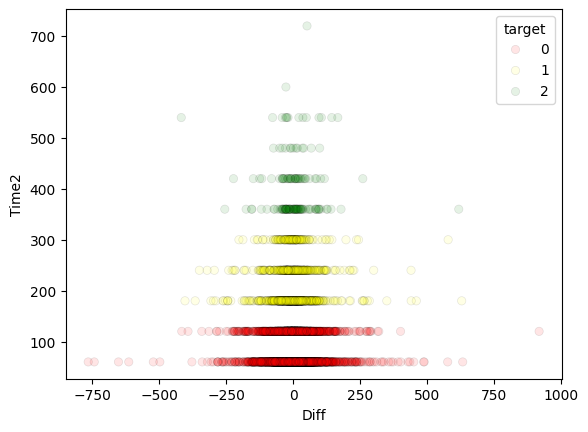

In [9]:
custom_colors = {
    0: 'red', 
    1: 'yellow', 
    2: 'green'
}
sns.scatterplot(df,x='Diff',y='Time2',hue='target',palette=custom_colors,
                alpha=0.1,edgecolor='k',linewidth=0.5)

<Axes: xlabel='Diff', ylabel='Time1'>

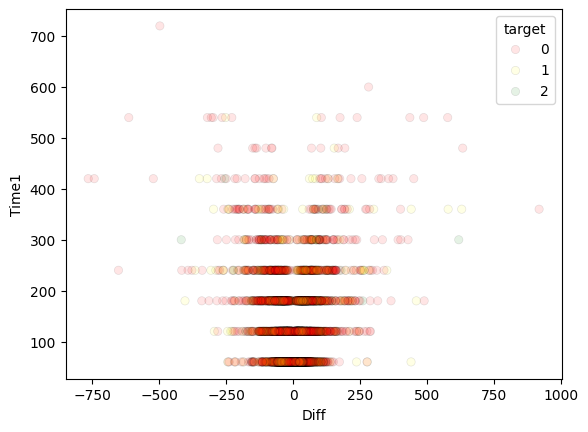

In [10]:
sns.scatterplot(df,x='Diff',y='Time1',hue='target',palette=custom_colors,
                alpha=0.1,edgecolor='k',linewidth=0.5)

<Axes: xlabel='Time1', ylabel='Time2'>

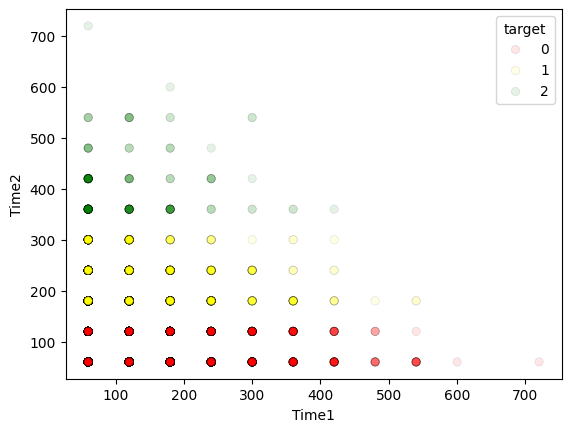

In [11]:
sns.scatterplot(df,x='Time1',y='Time2',hue='target',palette=custom_colors,
                alpha=0.1,edgecolor='k',linewidth=0.5)

<Axes: xlabel='Diff', ylabel='Count'>

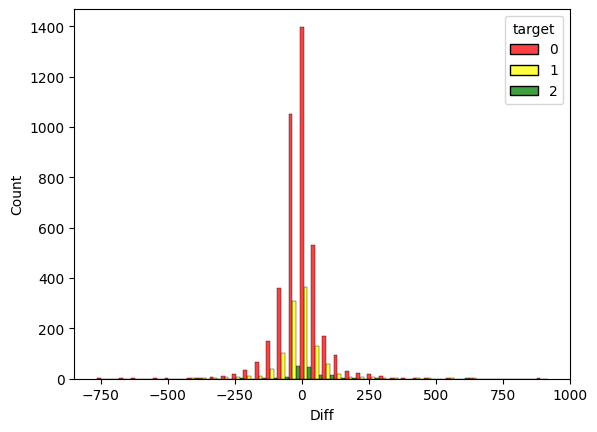

In [13]:
sns.histplot(
    data=df,
    x='Diff',
    hue='target',           # Groups the counts by your 0, 1, 2 column
    palette={0: 'red', 1: 'yellow', 2: 'green'}, # Enforces traffic light colors
    bins=40,                        # Chops the Diff axis into 40 distinct ranges
    multiple='dodge',               # 'dodge' puts the bars side-by-side for easy comparison
    edgecolor='black'               # Adds a black border to make bars pop
)